In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


In [3]:
def log_transform(X):
	"""Custom log transformation function"""
	return np.log1p(X)

preprocessor = joblib.load("C:\\Users\\xws\\Desktop\\credit-risk-ml\\artifacts\\preprocessor.joblib")

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log',
                                                  FunctionTransformer(func=<function log_transform at 0x0000017FC3094540>)),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'no_of_days_employed',
                                  'total_family_members', 'migrant_worker',
                                  'yearly_debt_payments', 'credit_limit',
                                  'credit_limit_used(%)', 'credit_score',
                                  'prev_defaults', 'default_in_last_6months']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_fre

In [4]:
train_path = 'C:\\Users\\xws\\Desktop\\credit-risk-ml\\data\\train (1).csv'
test_path = 'C:\\Users\\xws\\Desktop\\credit-risk-ml\\data\\test.csv'

# Chargement
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X = train_df.drop(columns=["customer_id", "name", "credit_card_default"])
y = train_df["credit_card_default"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

print("Default ratio train:", y_train.mean())
print("Default ratio valid:", y_valid.mean())

Train: (36422, 16)
Valid: (9106, 16)
Default ratio train: 0.08121465048597001
Default ratio valid: 0.08115528223149572


In [5]:
def evaluate_proba_model(model_pipe, X_tr, y_tr, X_va, y_va, name="model"):
    model_pipe.fit(X_tr, y_tr)
    proba = model_pipe.predict_proba(X_va)[:, 1]
    pred05 = (proba >= 0.5).astype(int)

    metrics = {
        "model": name,
        "F1@0.5": f1_score(y_va, pred05),
        "Precision@0.5": precision_score(y_va, pred05),
        "Recall@0.5": recall_score(y_va, pred05),
        "ROC_AUC": roc_auc_score(y_va, proba),
        "PR_AUC(AP)": average_precision_score(y_va, proba),
    }
    return metrics, proba

def tune_threshold_for_f1(y_true, proba, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 181)
    best = {"threshold": None, "f1": -1, "precision": None, "recall": None}
    for t in grid:
        pred = (proba >= t).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best["f1"]:
            best["threshold"] = float(t)
            best["f1"] = float(f1)
            best["precision"] = float(precision_score(y_true, pred))
            best["recall"] = float(recall_score(y_true, pred))
    return best

In [6]:
candidates = []

# 1) Logistic Regression (ton baseline pro, avec class_weight)
lr_balanced = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        random_state=42
    ))
])
candidates.append(("LogReg_balanced", lr_balanced))

# 2) RandomForest (class_weight helps imbalance)
rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ))
])
candidates.append(("RandomForest", rf))

xgb = Pipeline([
        ("preprocessing", preprocessor),
        ("model", XGBClassifier(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ))
    ])
candidates.append(("XGBoost", xgb))

In [7]:
all_results = []
probas_dict = {}

for name, pipe in candidates:
    metrics, proba = evaluate_proba_model(pipe, X_train, y_train, X_valid, y_valid, name=name)
    all_results.append(metrics)
    probas_dict[name] = proba

results_df = pd.DataFrame(all_results).sort_values("PR_AUC(AP)", ascending=False)
display(results_df)

,model,F1@0.5,Precision@0.5,Recall@0.5,ROC_AUC,PR_AUC(AP)
2,XGBoost,0.862745,0.931034,0.803789,0.995554,0.958830
1,RandomForest,0.856749,0.872370,0.841678,0.995413,0.957502
0,LogReg_balanced,0.774440,0.649267,0.959405,0.993942,0.948959


In [8]:
best_name = results_df.iloc[0]["model"]
best_proba = probas_dict[best_name]

best_thr_stats = tune_threshold_for_f1(y_valid, best_proba)
print("Best model:", best_name)
print("Best threshold:", best_thr_stats["threshold"])
print("Best F1:", round(best_thr_stats["f1"], 4))
print("Precision/Recall:", round(best_thr_stats["precision"], 4), round(best_thr_stats["recall"], 4))

Best model: XGBoost
Best threshold: 0.36999999999999994
Best F1: 0.8693
Precision/Recall: 0.8839 0.8552


Confusion matrix:
 [[8284   83]
 [ 107  632]]


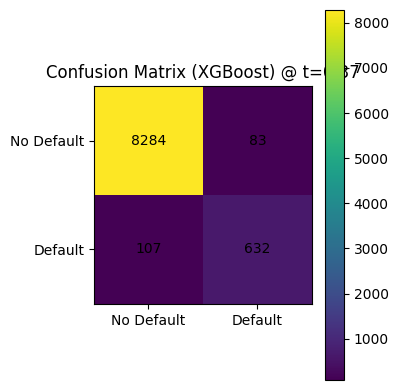

In [9]:
t = best_thr_stats["threshold"]
pred_opt = (best_proba >= t).astype(int)

cm = confusion_matrix(y_valid, pred_opt)
print("Confusion matrix:\n", cm)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title(f"Confusion Matrix ({best_name}) @ t={t:.2f}")
plt.xticks([0,1],["No Default","Default"])
plt.yticks([0,1],["No Default","Default"])
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [12]:
cv_ap = cross_val_score(
    best_pipe,
    X,
    y,
    cv=skf,
    scoring="average_precision",
    n_jobs=-1
)

cv_f1 = cross_val_score(
    best_pipe,
    X,
    y,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

print("CV AP:", np.round(cv_ap,4), "Mean:", cv_ap.mean())
print("CV F1:", np.round(cv_f1,4), "Mean:", cv_f1.mean())

CV AP: [0.9501 0.9497 0.9556 0.9464 0.9575] Mean: 0.951854163686259
CV F1: [0.8509 0.8557 0.8635 0.8466 0.8609] Mean: 0.8555278551303418


In [ ]:
import joblib
from pathlib import Path

# Fit final model
best_pipe.fit(X, y)

# threshold final
t_final = best_thr_stats["threshold"]

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

joblib.dump(best_pipe,
            ARTIFACTS/"credit_default_xgb_pipeline.joblib")

joblib.dump(t_final,
            ARTIFACTS/"decision_threshold_xgb.joblib")

print("✅ Model + threshold saved")

✅ Model + threshold saved


In [14]:
X_test = test_df.drop(
    columns=["customer_id","name"],
    errors="ignore"
)

proba_test = best_pipe.predict_proba(X_test)[:,1]
pred_test = (proba_test >= t_final).astype(int)

submission = pd.DataFrame({
    "customer_id": test_df["customer_id"],
    "credit_card_default": pred_test
})

submission.to_csv(
    "C:\\Users\\xws\\Desktop\\credit-risk-ml\\artifacts\\submission.csv",
    index=False
)

submission.head()

C:\Users\xws\AppData\Local\Temp\ipykernel_36300\1754537197.py:3: RuntimeWarning: invalid value encountered in log1p
  return np.log1p(X)


,customer_id,credit_card_default
0,CST_142525,0
1,CST_129215,0
2,CST_138443,1
3,CST_123812,0
4,CST_144450,1
